# Do not push this file

In [36]:
import logging

logging.basicConfig(
    filename=f"dev.log",
    filemode="a",
    format="{asctime} {levelname} {filename}:{lineno}: {message}",
    datefmt="%Y-%m-%d %H:%M:%S",
    style="{",
    level=logging.INFO,  # Qiskit dumps too many DEBUG messages
    encoding="utf-8",
)

In [4]:
import json
from numpy import linspace

with open("configs/noise_large.json", "r") as f:
    noise_params = json.load(f)
    noise = linspace(**noise_params)
    del noise_params

In [5]:
print(len(noise))
print(noise)

41
[0.     0.0025 0.005  0.0075 0.01   0.0125 0.015  0.0175 0.02   0.0225
 0.025  0.0275 0.03   0.0325 0.035  0.0375 0.04   0.0425 0.045  0.0475
 0.05   0.0525 0.055  0.0575 0.06   0.0625 0.065  0.0675 0.07   0.0725
 0.075  0.0775 0.08   0.0825 0.085  0.0875 0.09   0.0925 0.095  0.0975
 0.1   ]


## Check the states' inner products and show it as a table

In [6]:
from pprint import pprint

In [ ]:
from flow.problem_spec import *
from temp.get_random_seeds import get_random_seeds

states_q2_n3_s0 = ProblemSpec.gen_states(2, 3, get_random_seeds(3, 0))
states_q2_n3_s1 = ProblemSpec.gen_states(2, 3, get_random_seeds(3, 1))
states_q2_n3_s2 = ProblemSpec.gen_states(2, 3, get_random_seeds(3, 2))
states_q2_n3_s3 = ProblemSpec.gen_states(2, 3, get_random_seeds(3, 3))
states_q2_n3_s4 = ProblemSpec.gen_states(2, 3, get_random_seeds(3, 4))

from utils.inner_product import inner_products_table

print("q2_n3_s0")
inner_products_table(states_q2_n3_s0)
print()
print("q2_n3_s1")

inner_products_table(states_q2_n3_s1)
print()
print("q2_n3_s2")
inner_products_table(states_q2_n3_s2)
print()
print("q2_n3_s3")
inner_products_table(states_q2_n3_s3)
print()
print("q2_n3_s4")
inner_products_table(states_q2_n3_s4)

q2_n3_s0

Inner Product Table:
----------------------------------------------------------------------
|  States   |     State 0      |     State 1      |     State 2      |
--------------------------------------------------------------------
|  State 0  |      1.000       |      0.122       |      0.598       |
|  State 1  |      0.122       |      1.000       |      0.263       |
|  State 2  |      0.598       |      0.263       |      1.000       |
----------------------------------------------------------------------

q2_n3_s1

Inner Product Table:
----------------------------------------------------------------------
|  States   |     State 0      |     State 1      |     State 2      |
--------------------------------------------------------------------
|  State 0  |      1.000       |      0.394       |      0.620       |
|  State 1  |      0.394       |      1.000       |      0.588       |
|  State 2  |      0.620       |      0.588       |      1.000       |
------------------

array([[ 1.        +0.j        , -0.5813947 +0.2674704j ,
        -0.32182558-0.69226165j],
       [-0.5813947 -0.2674704j ,  1.        +0.j        ,
        -0.02532195+0.4579851j ],
       [-0.32182558+0.69226165j, -0.02532195-0.4579851j ,
         1.        +0.j        ]])

# Question: In what conditions is this useful?

## Example: Modified Blah blah protocol

## Our problem formulation

The formulas of different quantum states
- double-trine states (?)
- quantum change point problem
- eigenstates of MUB
- SIC states
- symmetric pure states
- non-orthogonal states
- W-states

one-qubit, 2 states


In [8]:
# Generate quantum states
from toqito.states import trine

In [9]:
print(trine())
psi1, psi2, psi3 = trine()

[array([[1],
       [0]]), array([[-0.5      ],
       [-0.8660254]]), array([[-0.5      ],
       [ 0.8660254]])]


In [10]:
# Try to solve it
DensityMatrix(psi1)
DensityMatrix(psi2)
DensityMatrix(psi3)

DensityMatrix([-0.5      +0.j,  0.8660254+0.j],
              dims=(2,))


## Coherent states


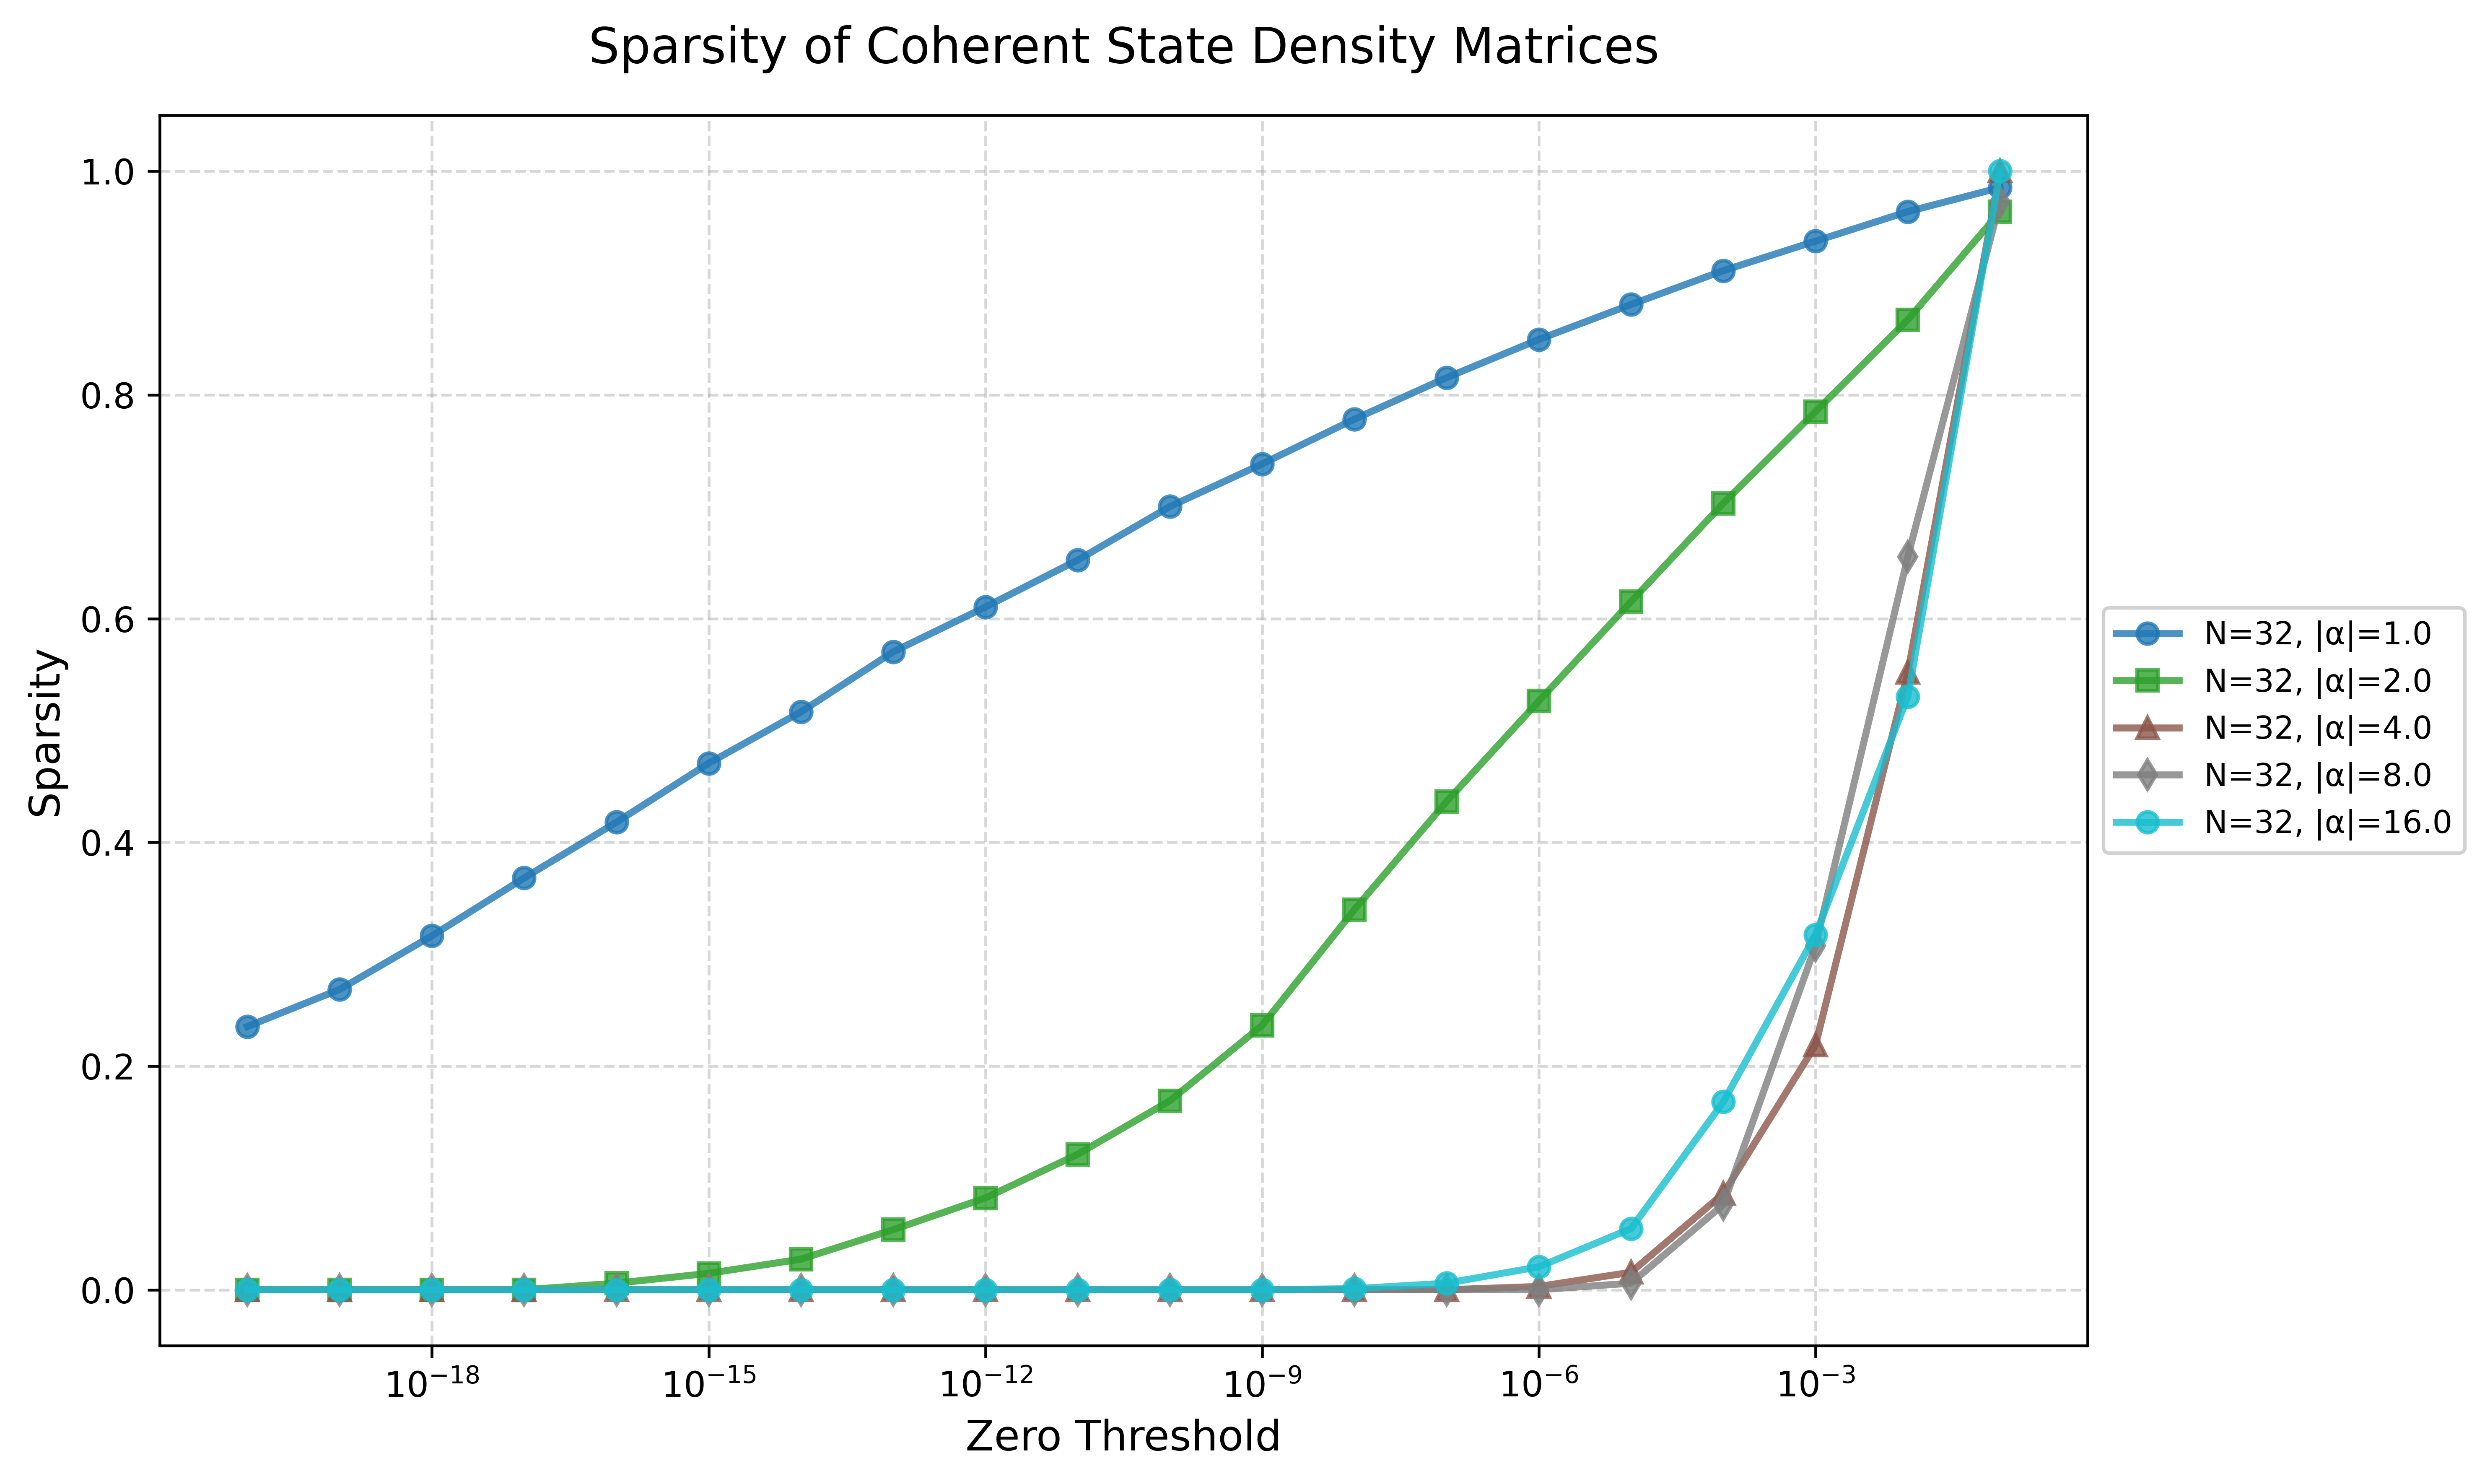

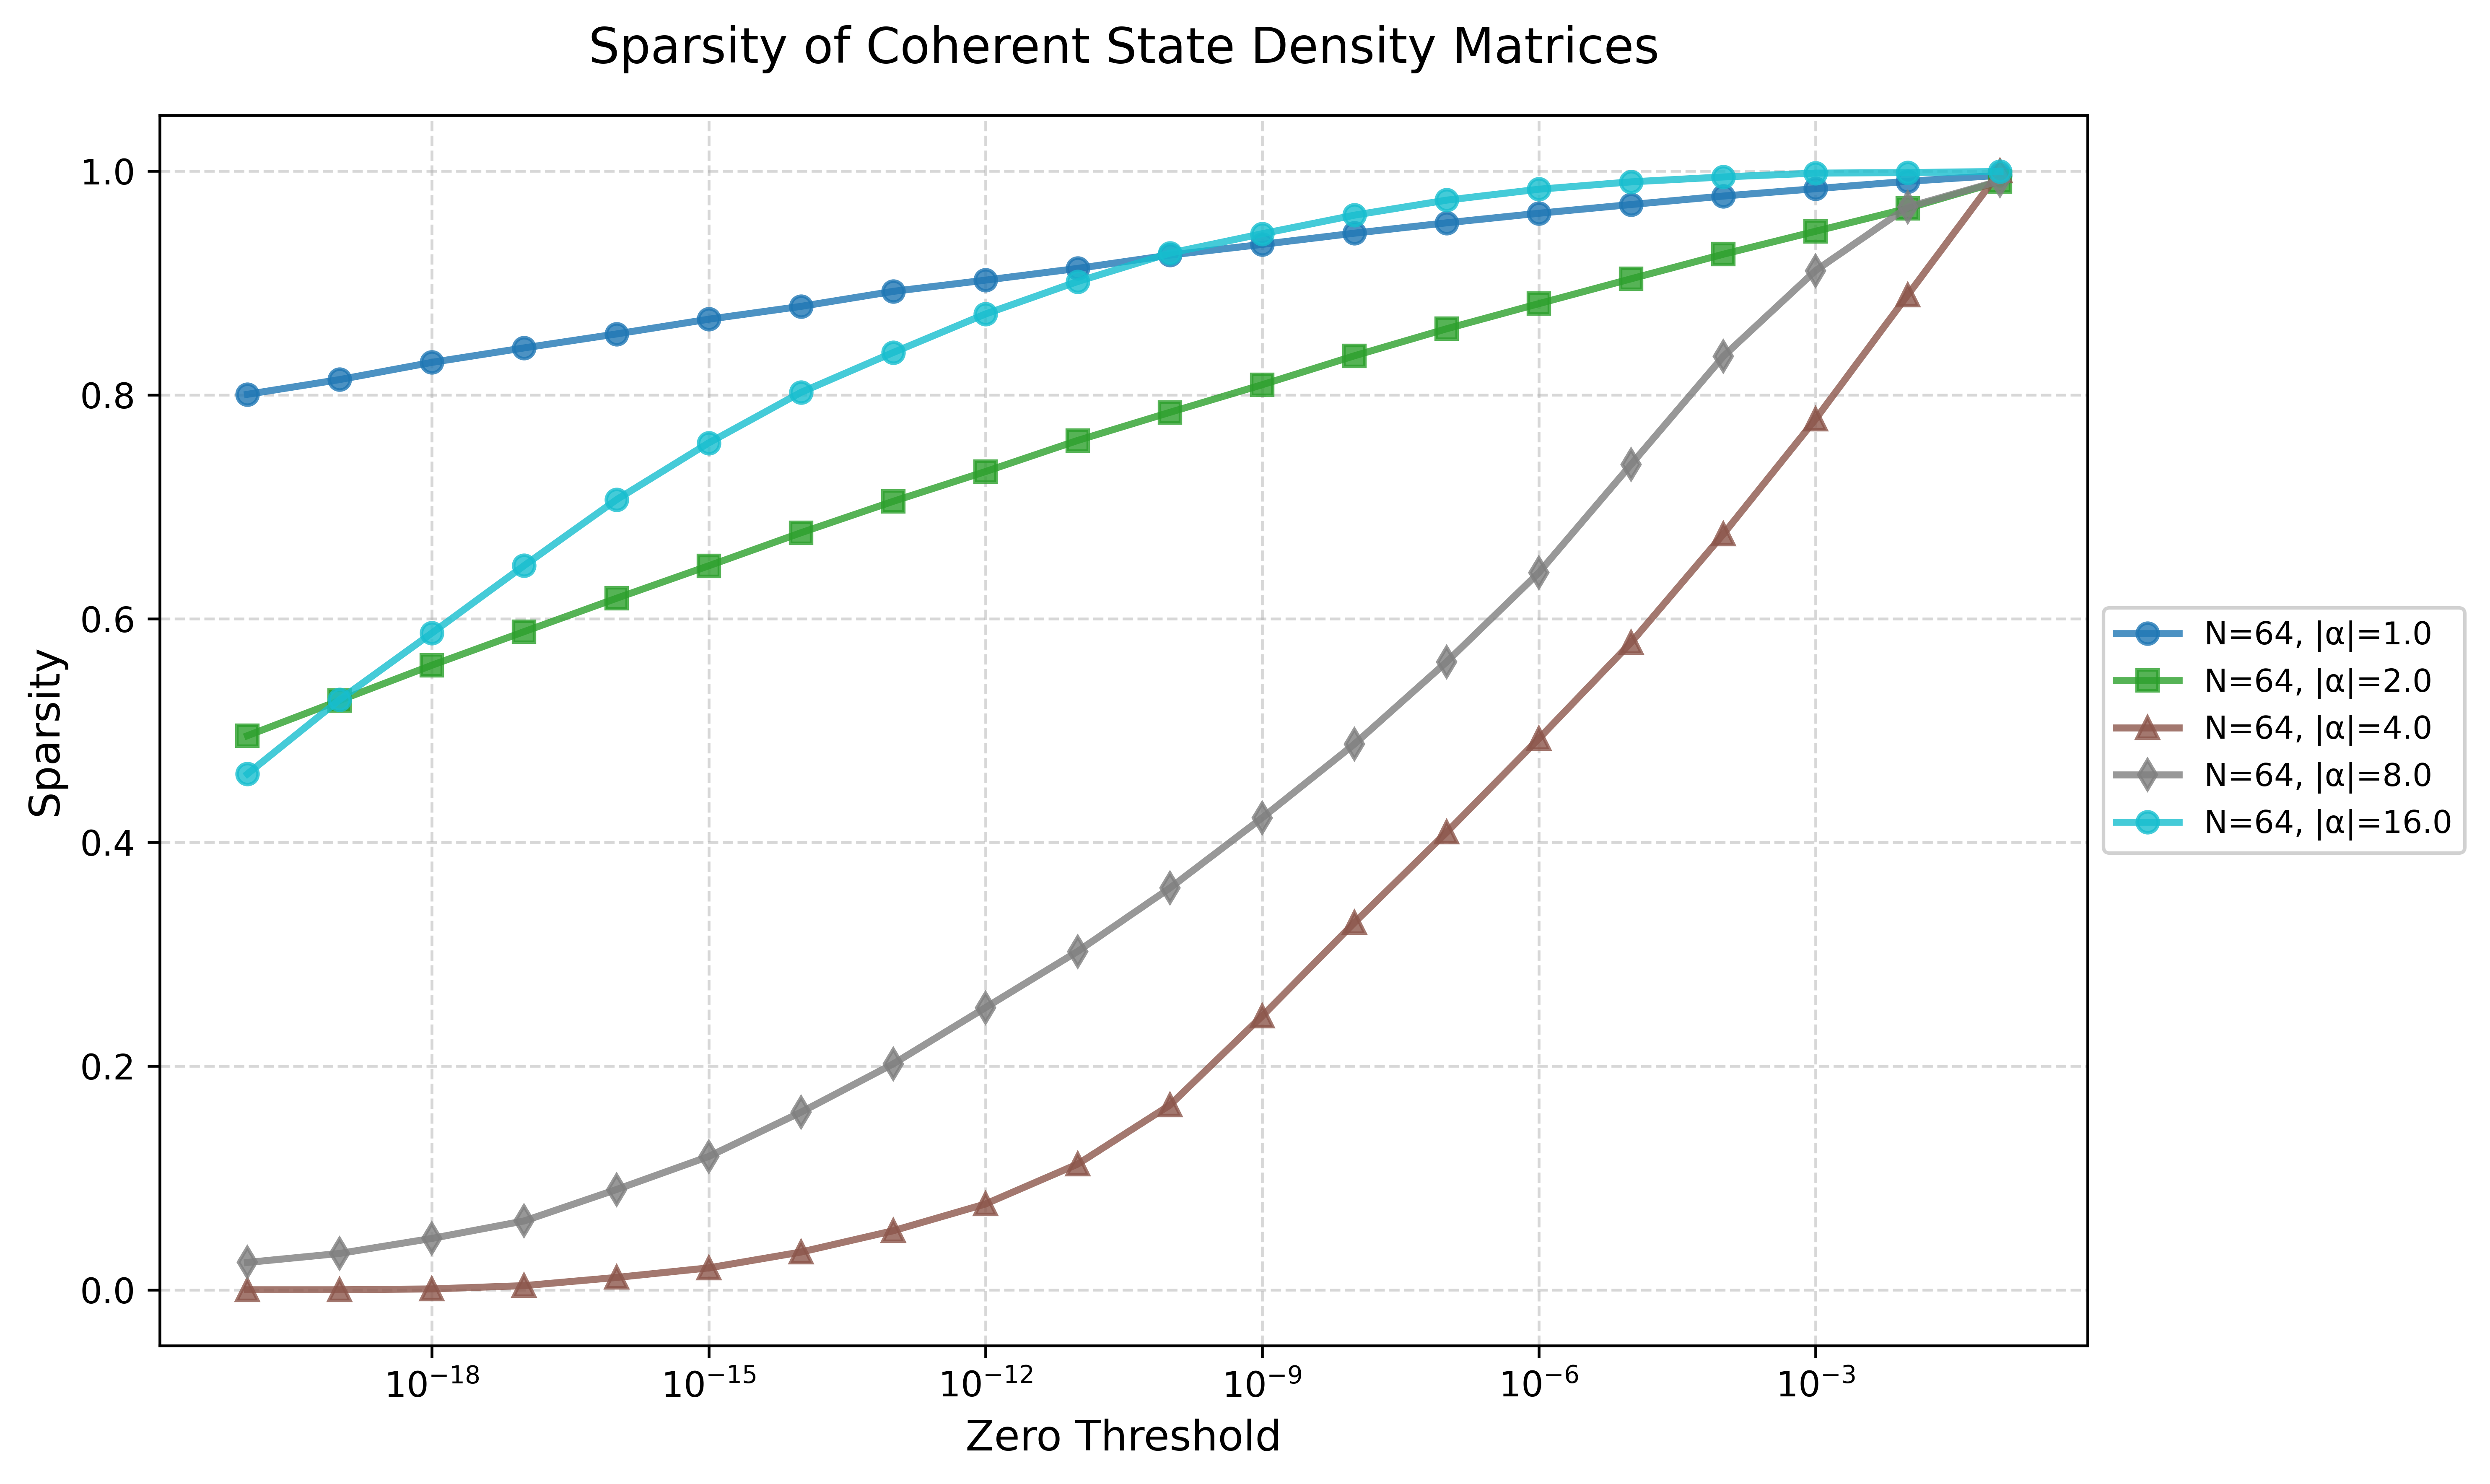

<Axes: >

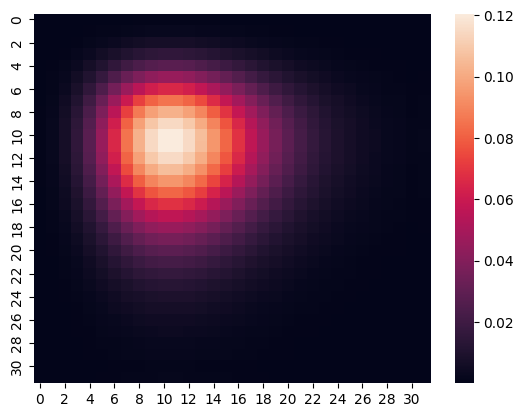

In [ ]:
n = 32
coh_n32_2 = coherent_dm(N=n, alpha=alpha_arr[1] * 8)
coh_n32_2_2d = abs(coh_n32_2.data.to_array()).reshape((n, n))
heatmap(coh_n32_2_2d)

In [53]:
coh_n32_2_pure = coherent(N=n, alpha=alpha_arr[1] * 8).data.to_array()
total_elements = coh_n32_2_pure.size
zero_elements = np.sum(np.abs(coh_n32_2_pure) < 1e-7)
sparsity = zero_elements / total_elements
print(sparsity)
print(coh_n32_2_pure)

0.0
[[-8.6173e-05-8.0279e-17j]
 [-3.0702e-04+3.0702e-04j]
 [-5.5777e-17+1.5090e-03j]
 [ 2.9548e-03+2.9548e-03j]
 [ 9.7862e-03+2.9690e-17j]
 [ 1.4167e-02-1.4167e-02j]
 [ 8.2438e-18-3.6637e-02j]
 [-4.2977e-02-4.2977e-02j]
 [-9.2567e-02+6.0934e-17j]
 [-9.2424e-02+9.2424e-02j]
 [ 1.3432e-16+1.7254e-01j]
 [ 1.5164e-01+1.5164e-01j]
 [ 2.5261e-01-3.8658e-16j]
 [ 2.0054e-01-2.0054e-01j]
 [-5.4923e-16-3.0504e-01j]
 [-2.2326e-01-2.2326e-01j]
 [-3.1579e-01+6.9137e-16j]
 [-2.1656e-01+2.1656e-01j]
 [ 6.2785e-16+2.8891e-01j]
 [ 1.8799e-01+1.8799e-01j]
 [ 2.3918e-01-5.7717e-16j]
 [ 1.4912e-01-1.4912e-01j]
 [-4.2431e-16-1.8246e-01j]
 [-1.0984e-01-1.0984e-01j]
 [-1.3006e-01+5.3666e-16j]
 [-7.6122e-02+7.6122e-02j]
 [ 3.7545e-16+8.7519e-02j]
 [ 5.0198e-02+5.0198e-02j]
 [ 5.5918e-02-2.2124e-16j]
 [ 3.1918e-02-3.1918e-02j]
 [-2.6170e-16-3.3811e-02j]
 [-2.0034e-02-2.0034e-02j]
 [-1.8760e-02+2.1077e-16j]
 [-1.3102e-02+1.3102e-02j]
 [ 1.0272e-16+8.2355e-03j]
 [ 9.9445e-03+9.9445e-03j]]


<Axes: >

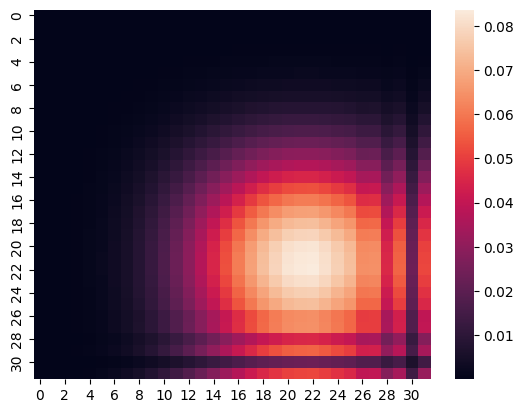

In [17]:
n = 32
coh_n32_2 = coherent_dm(N=n, alpha=alpha_arr[1] * 16)
coh_n32_2_2d = abs(coh_n32_2.data.to_array()).reshape((n, n))
heatmap(coh_n32_2_2d)

<Axes: >

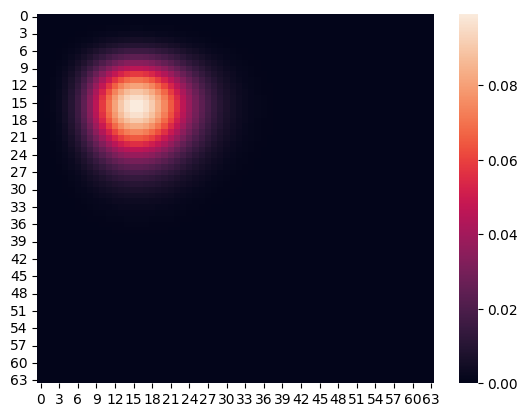

In [18]:
n = 64
coh_n32_2 = coherent_dm(N=n, alpha=alpha_arr[1] * 4)
coh_n32_2_2d = abs(coh_n32_2.data.to_array()).reshape((n, n))
heatmap(coh_n32_2_2d)

<Axes: >

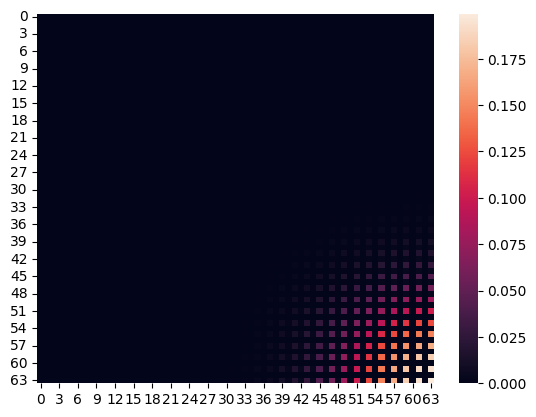

In [19]:
n = 64
coh_n32_2 = coherent_dm(N=n, alpha=alpha_arr[1] * 8)
coh_n32_2_2d = abs(coh_n32_2.data.to_array()).reshape((n, n))
heatmap(coh_n32_2_2d)

<Axes: >

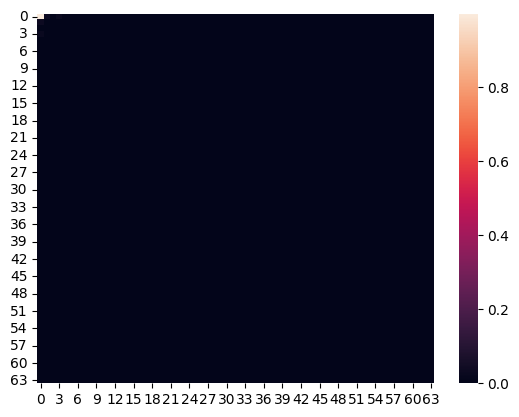

In [20]:
n = 64
coh_n32_2 = coherent_dm(N=n, alpha=alpha_arr[1] * 16)
coh_n32_2_2d = abs(coh_n32_2.data.to_array()).reshape((n, n))
heatmap(coh_n32_2_2d)

<Axes: >

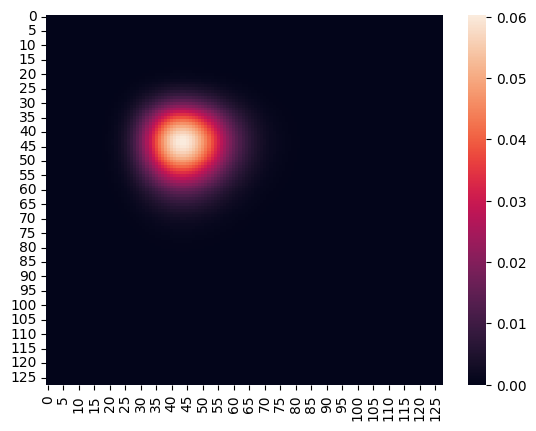

In [21]:
n = 128
coh_n32_2 = coherent_dm(N=n, alpha=alpha_arr[1] * 16)
coh_n32_2_2d = abs(coh_n32_2.data.to_array()).reshape((n, n))
heatmap(coh_n32_2_2d)

### Discrimination of coherent states: preliminary explorations

#### Pure state unambiguous discrimination

#### Mixed state epsilon-unambiguous discrimination

In [33]:
coh_states_pure_dm = [coherent_dm(N=32, alpha=alpha).data.to_array() for alpha in alpha_arr]

In [64]:
problem_coh.set_states(
    state_type="densitymatrix",
    states=coh_states_pure_dm,
    overwrite=True,
)

print(0)
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0] * 4,
    beta=[0] * 4,
)

0
Result = 0.24561556650669342
CVXPY returns optimal_inaccurate
Solution for PI_0 =
[[ 5.0488e-02+0.0000e+00j  2.9915e-02-2.9915e-02j  8.2399e-09-5.9443e-02j
  ...  5.8141e-12+2.8588e-13j  1.9242e-12+9.8943e-13j
   2.5462e-12+4.9564e-12j]
 [ 2.9915e-02+2.9915e-02j  4.3720e-02+0.0000e+00j  4.1775e-02-4.1775e-02j
  ...  6.2280e-12+4.8127e-12j  3.9111e-12+5.5879e-12j
   7.2015e-13-4.5102e-12j]
 [ 8.2399e-09+5.9443e-02j  4.1775e-02+4.1775e-02j  8.3509e-02+0.0000e+00j
  ...  5.8514e-12+9.2317e-11j  3.4872e-11+9.7069e-11j
  -2.2642e-12+1.9062e-11j]
 ...
 [ 5.8141e-12-2.8588e-13j  6.2280e-12-4.8127e-12j  5.8514e-12-9.2317e-11j
  ...  2.0000e-01+0.0000e+00j  6.5220e-09-2.0353e-10j
   2.1915e-09+4.4136e-10j]
 [ 1.9242e-12-9.8943e-13j  3.9111e-12-5.5879e-12j  3.4872e-11-9.7069e-11j
  ...  6.5220e-09+2.0353e-10j  2.0000e-01+0.0000e+00j
   7.8349e-09+2.0702e-09j]
 [ 2.5462e-12-4.9564e-12j  7.2015e-13+4.5102e-12j -2.2642e-12-1.9062e-11j
  ...  2.1915e-09-4.4136e-10j  7.8349e-09-2.0702e-09j
   2.000

/home/koova22/miniconda3/envs/q1/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [ ]:
# Read results


In [ ]:
import sys

sys.path.append("./flow")
from flow.solve_mix import *

problem_coh = ProblemSpec(
    num_qubits=2,
    num_states=4,
    seed=33,
    prior_prob=[0.25] * 4,
    state_type="densitymatrix",
)

In [ ]:
problem_coh.set_states(
    state_type="densitymatrix",
    states=coh_states,
    overwrite=True,
)

print(0)
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0] * 4,
    beta=[0] * 4,
)
print(1e-8)
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[1e-8] * 4,
    beta=[1e-8] * 4,
)

print(0.01)
result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.01] * 4,
    beta=[0.01] * 4,
)

result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.02] * 4,
    beta=[0.02] * 4,
)

result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.04] * 4,
    beta=[0.04] * 4,
)

result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.5] * 4,
    beta=[0.5] * 4,
)

result = apply_crossQD(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    alpha=[0.45] * 4,
    beta=[0.45] * 4,
)

0


/home/koova22/miniconda3/envs/q1/lib/python3.12/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Result = 0.3616246044072553
CVXPY returns optimal_inaccurate
Solution for PI_0 =
[[ 6.1536e-02+0.j      4.3225e-02-0.0432j -2.5577e-16-0.0904j
  -8.7703e-02-0.0877j]
 [ 4.3225e-02+0.0432j  6.0726e-02+0.j      6.3521e-02-0.0635j
  -1.2768e-16-0.1232j]
 [-2.5577e-16+0.0904j  6.3521e-02+0.0635j  1.3288e-01+0.j
   1.2888e-01-0.1289j]
 [-8.7703e-02+0.0877j -1.2768e-16+0.1232j  1.2888e-01+0.1289j
   2.5000e-01+0.j    ]]
Solution for PI_1 =
[[ 6.1536e-02+0.j     -4.3225e-02-0.0432j -1.4586e-16+0.0904j
   8.7703e-02-0.0877j]
 [-4.3225e-02+0.0432j  6.0726e-02+0.j     -6.3521e-02-0.0635j
  -3.1848e-16+0.1232j]
 [-1.4586e-16-0.0904j -6.3521e-02+0.0635j  1.3288e-01+0.j
  -1.2888e-01-0.1289j]
 [ 8.7703e-02+0.0877j -3.1848e-16-0.1232j -1.2888e-01+0.1289j
   2.5000e-01+0.j    ]]
Solution for PI_2 =
[[ 6.1536e-02+0.j     -4.3225e-02+0.0432j  3.3798e-16-0.0904j
   8.7703e-02+0.0877j]
 [-4.3225e-02-0.0432j  6.0726e-02+0.j     -6.3521e-02+0.0635j
   2.2103e-16-0.1232j]
 [ 3.3798e-16+0.0904j -6.3521e-02-0

In [ ]:
result = apply_Eldar_mix_primal(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    beta=0.3,
)

result = apply_Eldar_mix_primal(
    problem_spec=problem_coh,
    prior_prob=[0.25] * 4,
    beta=0.1,
)

Result = 0.6811556594440729
CVXPY returns optimal
Solution for PI_0 =
[[ 1.4957e-01+0.j      1.0507e-01-0.1051j -3.2279e-17-0.1934j
  -1.3674e-01-0.1367j]
 [ 1.0507e-01+0.1051j  1.4760e-01+0.j      1.3583e-01-0.1358j
   2.2268e-16-0.1921j]
 [-3.2279e-17+0.1934j  1.3583e-01+0.1358j  2.5000e-01+0.j
   1.7678e-01-0.1768j]
 [-1.3674e-01+0.1367j  2.2268e-16+0.1921j  1.7678e-01+0.1768j
   2.5000e-01+0.j    ]]
Solution for PI_1 =
[[ 1.4957e-01+0.j     -1.0507e-01-0.1051j -1.7977e-16+0.1934j
   1.3674e-01-0.1367j]
 [-1.0507e-01+0.1051j  1.4760e-01+0.j     -1.3583e-01-0.1358j
  -4.4552e-17+0.1921j]
 [-1.7977e-16-0.1934j -1.3583e-01+0.1358j  2.5000e-01+0.j
  -1.7678e-01-0.1768j]
 [ 1.3674e-01+0.1367j -4.4552e-17-0.1921j -1.7678e-01+0.1768j
   2.5000e-01+0.j    ]]
Solution for PI_2 =
[[ 1.4957e-01+0.j     -1.0507e-01+0.1051j  8.0348e-17-0.1934j
   1.3674e-01+0.1367j]
 [-1.0507e-01-0.1051j  1.4760e-01+0.j     -1.3583e-01+0.1358j
  -1.2383e-16-0.1921j]
 [ 8.0348e-17+0.1934j -1.3583e-01-0.1358j  2.5

# Verifying the SIC states
It is very safe XD

In [ ]:
import numpy as np

sic_states_d2 = np.array(
    [
        [1, 0],
        [1 / np.sqrt(3), np.sqrt(2 / 3)],
        [1 / np.sqrt(3), np.sqrt(2 / 3) * np.exp(2j * np.pi / 3)],
        [1 / np.sqrt(3), np.sqrt(2 / 3) * np.exp(4j * np.pi / 3)],
    ]
)

In [ ]:
import sys

sys.path.append("./flow")
from flow.solve_mix import *

sic_states_d2_dm = [DensityMatrix(state) for state in sic_states_d2]

problem = ProblemSpec(
    num_qubits=1,
    num_states=4,
    seed=33,
    prior_prob=[0.25] * 4,
    state_type="densitymatrix",
)

problem.set_states(
    state_type="densitymatrix",
    states=sic_states_d2_dm,
    overwrite=True,
)

result = apply_crossQD(
    problem_spec=problem,
    prior_prob=[0.25] * 4,
    alpha=[0.5] * 4,
    beta=[0.5] * 4,
)

result = apply_crossQD(
    problem_spec=problem,
    prior_prob=[0.25] * 4,
    alpha=[0.45] * 4,
    beta=[0.45] * 4,
)

Result = 0.49999999995440403
CVXPY returns optimal
Solution for PI_0 =
[[5.0000e-01+0.00e+00j 1.0869e-10+6.75e-17j]
 [1.0869e-10-6.75e-17j 1.0986e-09+0.00e+00j]]
Solution for PI_1 =
[[0.1667+0.00e+00j 0.2357-4.98e-17j]
 [0.2357+4.98e-17j 0.3333+0.00e+00j]]
Solution for PI_2 =
[[ 0.1667+0.j     -0.1179-0.2041j]
 [-0.1179+0.2041j  0.3333+0.j    ]]
Solution for PI_3 =
[[ 0.1667+0.j     -0.1179+0.2041j]
 [-0.1179-0.2041j  0.3333+0.j    ]]
Solution for PI_4 =
[[ 9.8181e-11+0.0000e+00j -1.1798e-09+2.2849e-17j]
 [-1.1798e-09-2.2849e-17j -2.6788e-10+0.0000e+00j]]
bitstring_to_target_state
{0: 0, 1: 1, 2: 2, 3: 3}
strings_used
4
Probabilities for each state:
[0.12499999876668078, 0.041666667271042276, 0.04166666703096519, 0.04166666703096516]
[0.04166666628117813, 0.12500000082722101, 0.04166666658739112, 0.041666666587391134]
[0.041666666242751324, 0.04166666677808939, 0.12500000018025115, 0.04166666656189483]
[0.04166666624275135, 0.041666666778089334, 0.041666666561894876, 0.1250000001802511

In [ ]:
result = apply_Eldar_mix_primal(
    problem_spec=problem,
    prior_prob=[0.25] * 4,
    beta=0.3,
)

result = apply_Eldar_mix_primal(
    problem_spec=problem,
    prior_prob=[0.25] * 4,
    beta=0.1,
)

Result = 0.34999999999957576
CVXPY returns optimal
Solution for PI_0 =
[[ 3.5000e-01+0.0000e+00j -1.1295e-16-1.4189e-16j]
 [-1.1295e-16+1.4189e-16j  2.8470e-13+0.0000e+00j]]
Solution for PI_1 =
[[0.1167+0.0000e+00j 0.165 -1.4223e-16j]
 [0.165 +1.4223e-16j 0.2333+0.0000e+00j]]
Solution for PI_2 =
[[ 0.1167+0.j     -0.0825-0.1429j]
 [-0.0825+0.1429j  0.2333+0.j    ]]
Solution for PI_3 =
[[ 0.1167+0.j     -0.0825+0.1429j]
 [-0.0825-0.1429j  0.2333+0.j    ]]
Solution for PI_4 =
[[ 3.0000e-01+0.0000e+00j -1.1583e-15-1.3363e-14j]
 [-1.1583e-15+1.3363e-14j  3.0000e-01+0.0000e+00j]]
Probabilities for each state:
[0.0874999954707237, 0.029166667169872568, 0.029166667169870805, 0.029166667169873782, 0.07500000301949347]
[0.029166665156907877, 0.08750000150961784, 0.02916666716987106, 0.02916666716987377, 0.02499999761570829]
[0.029166665156907946, 0.029166667169872665, 0.08750000150961289, 0.029166667169873838, 0.025000036578441]
[0.02916666515690789, 0.02916666716987259, 0.029166667169871034, 0

In [ ]:
result = apply_Eldar_mix_primal(
    problem_spec=problem,
    prior_prob=[0.25] * 4,
    beta=0.001,
)

result = apply_Eldar_mix_primal(
    problem_spec=problem,
    prior_prob=[0.25] * 4,
    beta=0.00000,
)

Result = 0.4995000000033273
CVXPY returns optimal
Solution for PI_0 =
[[ 4.9950e-01+0.000e+00j -1.7825e-17-8.361e-17j]
 [-1.7825e-17+8.361e-17j -1.1194e-12+0.000e+00j]]
Solution for PI_1 =
[[0.1665+0.0000e+00j 0.2355-8.1616e-17j]
 [0.2355+8.1616e-17j 0.333 +0.0000e+00j]]
Solution for PI_2 =
[[ 0.1665+0.j     -0.1177-0.2039j]
 [-0.1177+0.2039j  0.333 +0.j    ]]
Solution for PI_3 =
[[ 0.1665+0.j     -0.1177+0.2039j]
 [-0.1177-0.2039j  0.333 +0.j    ]]
Solution for PI_4 =
[[1.0000e-03+0.000e+00j 1.3982e-15-3.126e-15j]
 [1.3982e-15+3.126e-15j 1.0000e-03+0.000e+00j]]
Probabilities for each state:
[0.12487500000378059, 0.04162499999994943, 0.04162499999994936, 0.04162499999995008, 1.1853548516211016e-11]
[0.04162500000126021, 0.12487499999984841, 0.04162499999994935, 0.04162499999994997, 0.00016668761901627799]
[0.04162500000126022, 0.04162499999994951, 0.12487499999984812, 0.041624999999950105, 0.00016669675924378173]
[0.041625000001260196, 0.04162499999994945, 0.041624999999949425, 0.12487

## Add noise and see if there is any difference

In [ ]:
noise_level = 0.3

disturbance_states = [
    DensityMatrix(ProblemSpec.depolarizing_noise_channel(1)) for _ in range(4)
]
# Combine these

combined_states = [
    (1 - noise_level) * sic_states_d2_dm[_].data
    + noise_level * disturbance_states[_].data
    for _ in range(4)
]

sic_states_d2_dm_noisy = [DensityMatrix(combined_states[_]) for _ in range(4)]

In [ ]:
problem_0_noisy = ProblemSpec(
    num_qubits=1,
    num_states=4,
    seed=33,
    prior_prob=[0.25] * 4,
    state_type="densitymatrix",
)

problem_0_noisy.set_states(
    state_type="densitymatrix",
    states=sic_states_d2_dm_noisy,
    overwrite=True,
)

In [ ]:
result_0_noisy = apply_crossQD(
    problem_spec=problem_0_noisy,
    prior_prob=[0.25] * 4,
    alpha=[0.57, 0.8, 0.8, 0.8],
    beta=[0.57, 0.8, 0.8, 0.8],
)

Result = -2.2476862082125847e-09
CVXPY returns optimal
Solution for PI_0 =
[[-2.2835e-08+0.0000e+00j  4.7988e-10+5.5851e-16j]
 [ 4.7988e-10-5.5851e-16j  1.1782e-08+0.0000e+00j]]
Solution for PI_1 =
[[-1.7117e-08+0.000e+00j -1.3863e-09+6.936e-16j]
 [-1.3863e-09-6.936e-16j  1.7250e-08+0.000e+00j]]
Solution for PI_2 =
[[-1.7096e-08+0.0000e+00j  1.3957e-09+1.5862e-09j]
 [ 1.3957e-09-1.5862e-09j  1.7296e-08+0.0000e+00j]]
Solution for PI_3 =
[[-1.7096e-08+0.0000e+00j  1.3957e-09-1.5862e-09j]
 [ 1.3957e-09+1.5862e-09j  1.7296e-08+0.0000e+00j]]
Solution for PI_4 =
[[ 1.0000e+00+0.0000e+00j -1.8864e-09+1.3213e-16j]
 [-1.8864e-09-1.3213e-16j  1.0000e+00+0.0000e+00j]]
bitstring_to_target_state
{0: 4, 1: 4}
strings_used
2
Probabilities for each state:
[0.21246730074013653, 0.03753271264440506]
[0.09358857371346385, 0.15641142326822666]
[0.09697208119966111, 0.15302791624888473]
[0.09697208147332803, 0.1530279159752179]
Total probability = 1.0000
Success probability = 0.0000
Inconclusive probabilit

In [ ]:
result_0_noisy = apply_Eldar_mix_primal(
    problem_spec=problem_0_noisy,
    prior_prob=[0.25] * 4,
    beta=0.3,
)

Result = 0.2975000000686435
CVXPY returns optimal
Solution for PI_0 =
[[ 3.5000e-01+0.0000e+00j  7.5423e-17-8.6064e-17j]
 [ 7.5423e-17+8.6064e-17j -5.2428e-11+0.0000e+00j]]
Solution for PI_1 =
[[0.1167+0.0000e+00j 0.165 -8.6059e-17j]
 [0.165 +8.6059e-17j 0.2333+0.0000e+00j]]
Solution for PI_2 =
[[ 0.1167+0.j     -0.0825-0.1429j]
 [-0.0825+0.1429j  0.2333+0.j    ]]
Solution for PI_3 =
[[ 0.1167+0.j     -0.0825+0.1429j]
 [-0.0825-0.1429j  0.2333+0.j    ]]
Solution for PI_4 =
[[3.0000e-01+0.0000e+00j 3.0794e-15-5.7234e-15j]
 [3.0794e-15+5.7234e-15j 3.0000e-01+0.0000e+00j]]
Probabilities for each state:
[0.07437496301921355, 0.0335416722373706, 0.03354167223737057, 0.033541672237371964, 0.06375002465068096]
[0.033541649989057114, 0.07437501235243045, 0.03354167223737057, 0.03354167223737194, 0.02875001177353407]
[0.03354164998905711, 0.03354167223737061, 0.07437501235243034, 0.03354167223737195, 0.028750011845483387]
[0.033541649989057086, 0.03354167223737057, 0.03354167223737052, 0.074375

## Try the subset of SIC states

In [ ]:
problem_1 = ProblemSpec(
    num_qubits=1,
    num_states=3,
    seed=33,
    prior_prob=[1 / 3] * 3,
    state_type="densitymatrix",
)

problem_1.set_states(
    state_type="densitymatrix",
    states=sic_states_d2_dm_noisy[:3],
    overwrite=True,
)

In [ ]:
result_1 = apply_crossQD(
    problem_spec=problem_1,
    prior_prob=[1 / 3] * 3,
    alpha=[0.55] * 3,
    beta=[0.55] * 3,
)
result_1 = apply_crossQD(
    problem_spec=problem_1,
    prior_prob=[1 / 3] * 3,
    alpha=[0.9, 0.3, 0.9],
    beta=[0.55] * 3,
)
result_1 = apply_crossQD(
    problem_spec=problem_1,
    prior_prob=[1 / 3] * 3,
    alpha=[0.9, 0.3, 0.9],
    beta=[0.9, 0.3, 0.9],
)

Result = 0.5533221097514273
CVXPY returns optimal
Solution for PI_0 =
[[ 0.6476+0.j     -0.0556+0.0962j]
 [-0.0556-0.0962j  0.0191+0.j    ]]
Solution for PI_1 =
[[0.1762+0.j     0.2778+0.0962j]
 [0.2778-0.0962j 0.4905+0.j    ]]
Solution for PI_2 =
[[ 0.1762+0.j     -0.2222-0.1925j]
 [-0.2222+0.1925j  0.4905+0.j    ]]
Solution for PI_3 =
[[-5.0873e-11+0.0000e+00j  6.5983e-12-1.1201e-11j]
 [ 6.5983e-12+1.1201e-11j -4.4727e-13+0.0000e+00j]]
bitstring_to_target_state
{0: 0, 1: 1, 2: 2}
strings_used
3
Probabilities for each state:
[0.18444070329786103, 0.07444631504102162, 0.07444631504077089]
[0.07444631507519531, 0.18444070323185838, 0.07444631505533456]
[0.07444631507561875, 0.0744463150560094, 0.1844407032307223]
Total probability = 1.0000
Success probability = 0.5533
Inconclusive probability = 0.0000

Result = 0.5481106164032229
CVXPY returns optimal
Solution for PI_0 =
[[ 0.55  +0.j     -0.1213+0.0492j]
 [-0.1213-0.0492j  0.0311+0.j    ]]
Solution for PI_1 =
[[0.2289+0.j     0.3588+0.

In [ ]:
result_1 = apply_Eldar_mix_primal(
    problem_spec=problem_1,
    prior_prob=[1 / 3] * 3,
    beta=0.01,
)
result_1 = apply_Eldar_mix_primal(
    problem_spec=problem_1,
    prior_prob=[1 / 3] * 3,
    beta=0.00000,
)

Result = 0.641903752169295
CVXPY returns optimal
Solution for PI_0 =
[[ 0.6419+0.j     -0.0563+0.0975j]
 [-0.0563-0.0975j  0.0198+0.j    ]]
Solution for PI_1 =
[[0.174 +0.j     0.2745+0.0975j]
 [0.2745-0.0975j 0.4876+0.j    ]]
Solution for PI_2 =
[[ 0.174 +0.j    -0.2217-0.189j]
 [-0.2217+0.189j  0.4876+0.j   ]]
Solution for PI_3 =
[[0.01  +0.j     0.0035-0.0061j]
 [0.0035+0.0061j 0.005 +0.j    ]]
Probabilities for each state:
[0.21396791738976512, 0.05801604130511771, 0.05801604130511785, 0.003333333333333579]
[0.05801604130511795, 0.21396791738976498, 0.05801604130511788, 0.0033333333333334866]
[0.05801604130511796, 0.05801604130511804, 0.2139679173897649, 0.0033333333333333166]
Total probability = 1.0000000000000027
Success probability = 0.641903752169295
Inconclusive probability = 0.010000000000000382

Result = 0.6476030138826937
CVXPY returns optimal
Solution for PI_0 =
[[ 0.6476+0.j     -0.0556+0.0962j]
 [-0.0556-0.0962j  0.0191+0.j    ]]
Solution for PI_1 =
[[0.1762+0.j     0.27

## Try noisy backend for circuits
Different assumptions lead to different objectives.
First, assume the input states are ideal and the measurement device contains a specific type of noise.
In this scenario, we say the receiver trusts the sources (ref. device indep.).
